In [25]:
import pandas as pd
import matplotlib.pyplot as plt
# import japanize_matplotlib  # Py3.12^ 未対応
import matplotlib_fontja # 後継

df = pd.read_csv("sample_pandas_6.csv")
df.head()


,発注日,商品番号,商品名,単価,在庫,注文数
0,2016-03-06,YY4HAAZR,商品サンプル YY4HAAZR,780,20,24
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12
2,2017-05-31,YY4HAAZR,商品サンプル YY4HAAZR,780,10,0
3,2022-10-26,1QJFO8QY,商品サンプル 1QJFO8QY,600,5,24
4,2016-06-10,1QJFO8QY,商品サンプル 1QJFO8QY,600,40,24


In [26]:
df.query('商品番号 == "Z4WOOIYV" and 在庫 >= 30')

,発注日,商品番号,商品名,単価,在庫,注文数
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12
5,2024-04-12,Z4WOOIYV,商品サンプル Z4WOOIYV,90,35,24
36,2024-08-29,Z4WOOIYV,商品サンプル Z4WOOIYV,90,35,0
71,2017-10-09,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,54
120,2020-02-12,Z4WOOIYV,商品サンプル Z4WOOIYV,90,50,24
130,2018-06-25,Z4WOOIYV,商品サンプル Z4WOOIYV,90,30,12
143,2023-12-10,Z4WOOIYV,商品サンプル Z4WOOIYV,90,35,30


In [27]:
def tax(x):
    return x * 1.10

tax_series= df['単価'].apply(tax)


In [28]:
tax_series.name = '単価（税込み）'
pd.concat([df,tax_series],axis=1)

,発注日,商品番号,商品名,単価,在庫,注文数,単価（税込み）
0,2016-03-06,YY4HAAZR,商品サンプル YY4HAAZR,780,20,24,858.0
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12,99.0
2,2017-05-31,YY4HAAZR,商品サンプル YY4HAAZR,780,10,0,858.0
3,2022-10-26,1QJFO8QY,商品サンプル 1QJFO8QY,600,5,24,660.0
4,2016-06-10,1QJFO8QY,商品サンプル 1QJFO8QY,600,40,24,660.0
...,...,...,...,...,...,...,...
195,2021-08-02,1QJFO8QY,商品サンプル 1QJFO8QY,600,10,42,660.0
196,2019-05-28,X0ZE2ZMY,商品サンプル X0ZE2ZMY,90,45,30,99.0
197,2015-06-22,48XMJXKO,商品サンプル 48XMJXKO,330,50,36,363.0
198,2022-08-29,QRMOGNUU,商品サンプル QRMOGNUU,420,40,48,462.0


In [29]:
category_df = pd.read_csv(r"../kadai_007/category.csv")
category_df.head()

,商品番号,カテゴリー
0,YY4HAAZR,弁当
1,Z4WOOIYV,飲料水
2,1QJFO8QY,弁当
3,MESUDVWQ,菓子類
4,S6RE8W6X,図書・新聞


In [30]:
# df = pd.merge(df,category_df,'inner',on='商品番号')
df = pd.merge(df, category_df[['商品番号', 'カテゴリー']], how='inner', on='商品番号')
df.head()

,発注日,商品番号,商品名,単価,在庫,注文数,カテゴリー
0,2016-03-06,YY4HAAZR,商品サンプル YY4HAAZR,780,20,24,弁当
1,2015-03-27,Z4WOOIYV,商品サンプル Z4WOOIYV,90,45,12,飲料水
2,2017-05-31,YY4HAAZR,商品サンプル YY4HAAZR,780,10,0,弁当
3,2022-10-26,1QJFO8QY,商品サンプル 1QJFO8QY,600,5,24,弁当
4,2016-06-10,1QJFO8QY,商品サンプル 1QJFO8QY,600,40,24,弁当


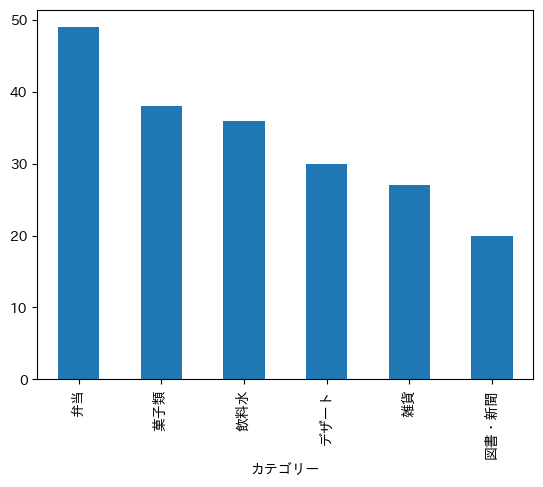

In [31]:
df['カテゴリー'].value_counts().plot(kind='bar')
plt.show()

In [32]:
df.groupby('商品番号')['注文数'].describe()

,count,mean,std,min,25%,50%,75%,max
商品番号,,,,,,,,
1QJFO8QY,32.0,35.250000,18.461818,0.0,24.0,36.0,49.5,60.0
2HSTCDWM,20.0,29.400000,21.137146,0.0,12.0,27.0,48.0,60.0
48XMJXKO,10.0,21.600000,13.326665,0.0,13.5,21.0,30.0,42.0
8T7D5DQA,21.0,25.142857,18.260027,0.0,12.0,36.0,42.0,54.0
MESUDVWQ,17.0,43.764706,18.219253,0.0,42.0,48.0,54.0,60.0
QRMOGNUU,27.0,33.111111,16.588535,6.0,21.0,36.0,48.0,60.0
S6RE8W6X,20.0,33.300000,21.631118,0.0,12.0,39.0,54.0,60.0
X0ZE2ZMY,14.0,21.857143,21.901377,0.0,1.5,15.0,39.0,60.0
YY4HAAZR,17.0,31.764706,18.095336,0.0,18.0,30.0,42.0,60.0
